In [40]:
print("Kavin T - 24BAD058")

Kavin T - 24BAD058


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [42]:
vocab_size = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))
print("Vocabulary size:", vocab_size)

Training samples: 25000
Testing samples: 25000
Vocabulary size: 10000


Positive training reviews: 12500
Negative training reviews: 12500


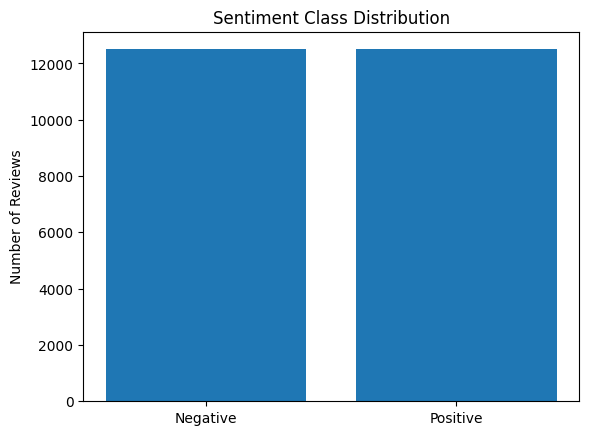

In [43]:
print("Positive training reviews:", np.sum(y_train == 1))
print("Negative training reviews:", np.sum(y_train == 0))

plt.bar(["Negative", "Positive"],
        [np.sum(y_train == 0), np.sum(y_train == 1)])

plt.title("Sentiment Class Distribution")
plt.ylabel("Number of Reviews")
plt.show()

In [44]:
word_index = imdb.get_word_index()

reverse_word_index = {value: key for key, value in word_index.items()}

decoded_review = " ".join(
    reverse_word_index.get(i - 3, "?") for i in x_train[0]
)

print(decoded_review)

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you thi

In [45]:
max_length = 200

x_train = pad_sequences(
    x_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

x_test = pad_sequences(
    x_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (25000, 200)
Testing shape: (25000, 200)


In [46]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training data:", x_train.shape)
print("Validation data:", x_val.shape)
print("Testing data:", x_test.shape)

Training data: (20000, 200)
Validation data: (5000, 200)
Testing data: (25000, 200)


In [47]:
embedding_dim = 128

embedding_layer = tf.keras.layers.Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_length
)

sample_embedding = embedding_layer(x_train[:1])

print("Embedding shape:", sample_embedding.shape)

Embedding shape: (1, 200, 128)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [48]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_length,)),

    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    tf.keras.layers.LSTM(64),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5276 - loss: 0.6914 - val_accuracy: 0.5660 - val_loss: 0.6735
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5942 - loss: 0.6473 - val_accuracy: 0.7256 - val_loss: 0.5881
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6339 - loss: 0.6084 - val_accuracy: 0.5688 - val_loss: 0.6674
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7738 - loss: 0.4788 - val_accuracy: 0.8144 - val_loss: 0.4584
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8862 - loss: 0.2948 - val_accuracy: 0.8278 - val_loss: 0.4394


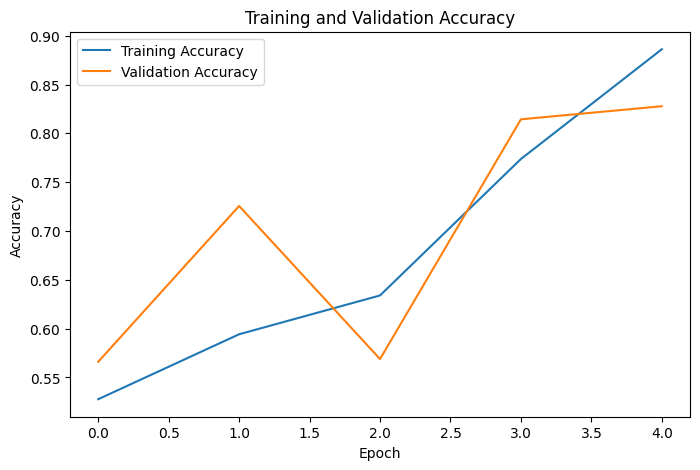

In [50]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

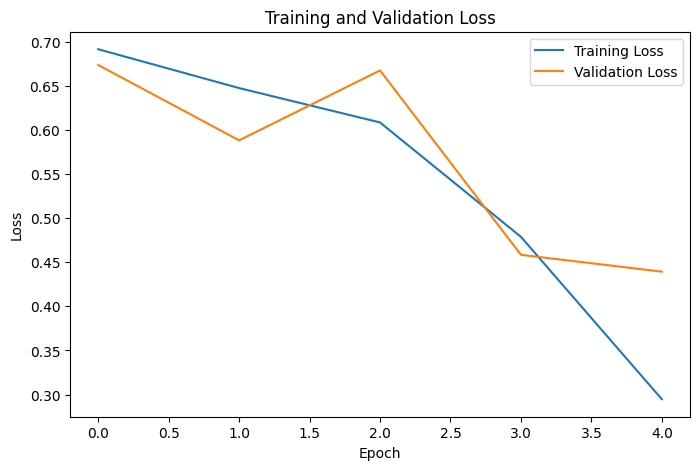

In [51]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [52]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8237 - loss: 0.4400
Test Loss: 0.44001609086990356
Test Accuracy: 0.8236799836158752


In [53]:
y_prob = model.predict(x_test)

y_pred = (y_prob >= 0.5).astype(int).flatten()

print("Predictions generated successfully.")

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Predictions generated successfully.


In [54]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.82368
Precision: 0.7849697140442315
Recall   : 0.8916
F1-Score : 0.8348939995505281


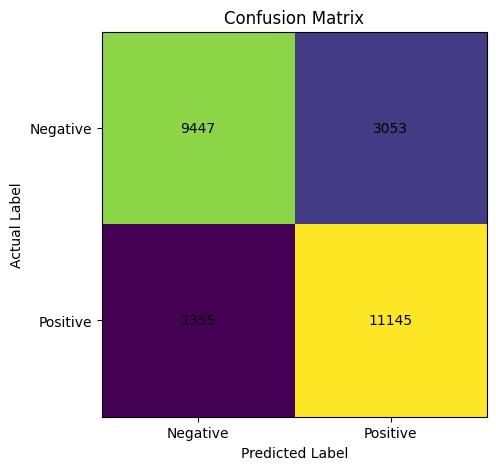

[[ 9447  3053]
 [ 1355 11145]]


In [55]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

print(cm)

In [56]:
sample_reviews = [
    "This movie was amazing and I really enjoyed it",
    "The movie was boring and disappointing"
]

In [57]:
tokenizer = imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()
    sequence = [tokenizer.get(word, 2) + 3 for word in words]
    return pad_sequences([sequence], maxlen=max_length, padding="post")

for review in sample_reviews:

    sequence = encode_review(review)

    prediction = model.predict(sequence, verbose=0)[0][0]

    if prediction >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print("Probability:", prediction)
    print()

Review: This movie was amazing and I really enjoyed it
Predicted Sentiment: Positive
Probability: 0.9261045

Review: The movie was boring and disappointing
Predicted Sentiment: Negative
Probability: 0.2783956

